In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [14]:
df = pd.read_csv('~/tweets/data/raw/twcs/twcs.csv')

In [15]:
data = df.copy()

In [16]:
data.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [7]:
# Missing info check
data.isnull().sum()

tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64

In [8]:
# Visualizing
data["customer_support_name"] = data['author_id'].str.extract('([a-zA-Z ]+)', expand=False).str.strip()

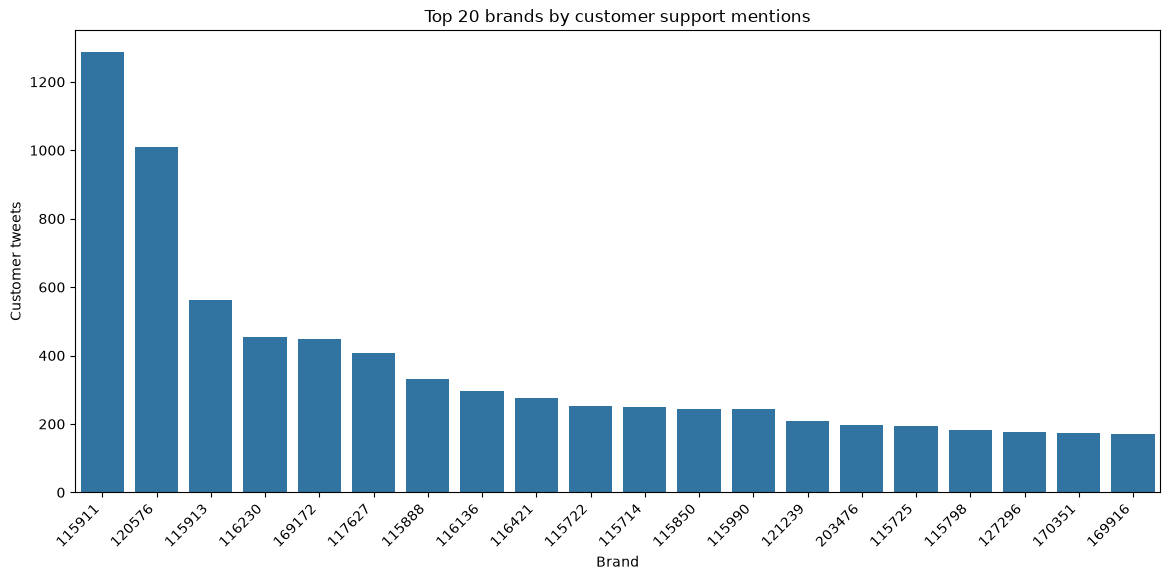

In [23]:
# customer messages per brand 
inbound = data[data["inbound"] == True]
demand = inbound["author_id"].value_counts().head(20)

plt.figure(figsize=(14, 6))
sns.barplot(x=demand.index, y=demand.values)
plt.title('Top 20 brands by customer support mentions')
plt.xlabel('Brand')
plt.ylabel('Customer tweets')
plt.xticks(rotation=45, ha='right')
plt.show()

In [24]:
replies = data[data["inbound"] == False]["author_id"].value_counts().head(15)
print(replies)

author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
SpotifyCares        43265
Delta               42253
Tesco               38573
AmericanAir         36764
TMobileHelp         34317
comcastcares        33031
British_Airways     29361
SouthwestAir        28977
VirginTrains        27817
Ask_Spectrum        25860
XboxSupport         24557
sprintcare          22381
Name: count, dtype: int64


In [26]:
brand = "AppleSupport"

brand_replies = data[(data["author_id"] == brand) & (~data["inbound"])]
thread_ids = set(brand_replies["in_response_to_tweet_id"].dropna().astype(int))

inbound = data[data["inbound"] & data["tweet_id"].isin(thread_ids)]

In [37]:
list(brand_replies["text"])[:10]

["@115854 We're here for you. Which version of the iOS are you running? Check from Settings &gt; General &gt; About.",
 "@115854 Lets take a closer look into this issue. Select the following link to join us in a DM and we'll go from there. https://t.co/GDrqU22YpT",
 "@115855 Let's go to DM for the next steps. DM us here: https://t.co/GDrqU22YpT",
 '@115855 Any steps tried since it started last night?',
 "@115855 That's great it has iOS 11.1 as we can rule out being outdated. Any steps tried since this started? Do you recall when it started?",
 "@115855 We'd like to look into this with you. Which model do you have and is iOS 11.1 installed? Any steps tried so far?",
 "@115856 Hey, let's work together to figure out what's going on. Meet us in DM and we'll continue from there. https://t.co/GDrqU22YpT",
 "@115857 We'd like to investigate further with you. Send us a DM and we can troubleshoot more from there. https://t.co/GDrqU22YpT",
 '@115857 Fill us in on what is happening, then we can h

In [43]:
def clean(text: str) -> str:
    text = str(text)
    text = re.sub(r"^RT @\w+:\s*", "", text)           # retweet prefix
    text = re.sub(r"@\w+", "[USER]", text)             # de-identify handles
    text = re.sub(r"https?://\S+|t\.co/\S+", "[LINK]", text)
    text = re.sub(r"&amp;", "&", text)
    return re.sub(r"\s+", " ", text).strip()

In [61]:
brand_threads = [clean(tweet) for tweet in inbound["text"]]

In [67]:
brand_threads[:20]

['[USER] The newest update. I️ made sure to download it yesterday.',
 '[USER] [LINK]',
 '[USER] Tried resetting my settings .. restarting my phone .. all that',
 '[USER] This is what it looks like [LINK]',
 '[USER] I️ have an iPhone 7 Plus and yes I️ do',
 '[USER] I️ need answers because it’s annoying 🙃',
 'Hey [USER] and anyone else who upgraded to ios11.1, are y’all having issues with capital “I️” in the Mail app? As it puts in “A”?',
 '[USER] This is what is happening... [LINK]',
 'Tf is wrong with my keyboard [USER]',
 '[USER] are the call centres closed for the night?',
 '[USER] [USER] hello are all the lines closed for tonight #help',
 '[USER] [USER] [USER] I️ upgraded. I️t didn’t work.',
 'Hello, internet. Can someone explain why this symbol keeps appearing on my phone and when I️ try to type the letter I️? Also [USER] [LINK]',
 '[USER] I’ve got a screenshot saying my #iPhoneX is reserved for the 3rd then an email saying it’s the 18th... what happened?',
 '[USER] I have the iPho

In [71]:
if df["inbound"].dtype != bool:
    df["inbound"] = df["inbound"].astype(str).str.lower().isin(["true", "1"])

for col in ["tweet_id", "in_response_to_tweet_id"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Loaded {len(df):,} tweets")

Loaded 2,811,774 tweets


In [72]:
df

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0
...,...,...,...,...,...,...,...
2811769,2987947,sprintcare,False,Wed Nov 22 08:43:51 +0000 2017,"@823869 Hey, we'd be happy to look into this f...",NaN,2987948.0
2811770,2987948,823869,True,Wed Nov 22 08:35:16 +0000 2017,@115714 wtf!? I’ve been having really shitty s...,2987947,NaN
2811771,2812240,121673,True,Thu Nov 23 04:13:07 +0000 2017,@143549 @sprintcare You have to go to https://...,NaN,2812239.0
2811772,2987949,AldiUK,False,Wed Nov 22 08:31:24 +0000 2017,"@823870 Sounds delicious, Sarah! 😋 https://t.c...",NaN,2987950.0


In [69]:
tweets = df.set_index("tweet_id")

In [70]:
tweets

,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
tweet_id,,,,,,
1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0
...,...,...,...,...,...,...
2987947,sprintcare,False,Wed Nov 22 08:43:51 +0000 2017,"@823869 Hey, we'd be happy to look into this f...",NaN,2987948.0
2987948,823869,True,Wed Nov 22 08:35:16 +0000 2017,@115714 wtf!? I’ve been having really shitty s...,2987947,NaN
2812240,121673,True,Thu Nov 23 04:13:07 +0000 2017,@143549 @sprintcare You have to go to https://...,NaN,2812239.0


In [73]:
children = {}
for tid, rid in zip(df["tweet_id"], df["response_tweet_id"]):
    if pd.isna(rid):
        continue
    for c in str(rid).split(","):
        c = c.strip()
        if c.isdigit():
            children.setdefault(int(tid), []).append(int(c))

In [80]:
import json
ref = [json.loads(l) for l in open("data/reference_library.jsonl")]
print(len(ref), "total,", len({r["brand_reply"] for r in ref}), "unique replies")

121078 total, 72883 unique replies


In [86]:
import json, random
held = [json.loads(l) for l in open("data/held_out.jsonl")]
random.seed(1)
for i, h in enumerate(random.sample(held, 60)):
    print(f"--- {i} ---\n{h['text'][:250]}\n")

--- 0 ---
This ios 11 is messing up my phone😤 [BRAND]

--- 1 ---
[USER] is a blessing

--- 2 ---
[USER] fuck this update i have the 7 and my phones still slow as fuck

--- 3 ---
why is my phone doing this [BRAND] [LINK]

--- 4 ---
[BRAND] I went on [LINK] and nothing showed up. I backed up from my phone when it restored and nothing showed up for about an hour or so

--- 5 ---
[BRAND] Let’s see if this works.... I

--- 6 ---
[BRAND] why does my battery drain 100x faster since the new update?

--- 7 ---
iPhone X Face ID/camera doesn’t work for me after having it for 2 days. Why you gotta do this to me [BRAND]?

--- 8 ---
[BRAND] 7+ and the newest version. Just link me IOS 10 bc iOS 11 trash and will always be trash

--- 9 ---
[BRAND] Forgot password for my itunes account. Spoke to Apple they said wait. Still waiting over a week later.

--- 10 ---
[BRAND] why did my battery life tank with the new update? Used to last all day. Now charging by 1pm

--- 11 ---
[BRAND] Seriously this update i

In [83]:
first_turns = {}
for h in held:
    first_turns.setdefault(h["thread_id"], h)  # turns were time-sorted, so first seen = earliest
held_first = list(first_turns.values())

In [10]:
apple = data[data["author_id"].eq("AppleSupport")].copy()
len(apple)

106860

In [11]:
display(apple.head())

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
396,696,AppleSupport,False,Tue Oct 31 22:27:49 +0000 2017,@115854 We're here for you. Which version of t...,697,698.0
398,699,AppleSupport,False,Tue Oct 31 22:36:27 +0000 2017,@115854 Lets take a closer look into this issu...,NaN,697.0
401,701,AppleSupport,False,Tue Oct 31 22:26:49 +0000 2017,@115855 Let's go to DM for the next steps. DM ...,NaN,702.0
403,703,AppleSupport,False,Tue Oct 31 22:09:52 +0000 2017,@115855 Any steps tried since it started last ...,702,704.0
405,705,AppleSupport,False,Tue Oct 31 21:57:00 +0000 2017,@115855 That's great it has iOS 11.1 as we can...,"706,704",707.0


In [75]:
# Finding customer tweets to AppleSupport
apple_replies = data[data["in_response_to_tweet_id"].isin(apple["tweet_id"])].copy()
print("Response Tweets to AppleSupport: ", len(apple_replies))
display(apple_replies.head(10))

Response Tweets to AppleSupport:  36660


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
397,697,115854,True,2017-10-31 22:31:23+00:00,@AppleSupport The newest update. I️ made sure ...,699,696.0
402,702,115855,True,2017-10-31 22:11:31+00:00,@AppleSupport Tried resetting my settings .. r...,701,703.0
404,704,115855,True,2017-10-31 21:59:17+00:00,@AppleSupport This is what it looks like https...,703,705.0
406,707,115855,True,2017-10-31 21:48:51+00:00,@AppleSupport I️ have an iPhone 7 Plus and yes...,705,708.0
412,713,115856,True,2017-10-31 22:35:17+00:00,@AppleSupport Just sent you all my DM,NaN,712.0
415,717,115857,True,2017-10-31 22:13:08+00:00,@AppleSupport This is what is happening... htt...,716,718.0
419,721,115859,True,2017-10-31 22:18:14+00:00,@AppleSupport are the call centres closed for ...,720,722.0
425,728,115862,True,2017-10-31 20:57:26+00:00,@AppleSupport @115861 We’re going to need you ...,727,729.0
431,735,115864,True,2017-10-31 22:23:35+00:00,@AppleSupport I have the iPhone 6s Plus and ju...,737,734.0
435,739,115865,True,2017-10-31 22:35:32+00:00,@AppleSupport iOS 11.0.3,741,738.0


In [76]:
apple_inbound = df[
    df["inbound"].eq(True) &
    (
        df["in_response_to_tweet_id"].isin(apple["tweet_id"]) |
        df["response_tweet_id"].isin(apple["tweet_id"])
    )
].copy()

print("Customer tweets linked to AppleSupport:", len(apple_inbound))
display(apple_inbound.head(10))

Customer tweets linked to AppleSupport: 36658


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
397,697,115854,True,Tue Oct 31 22:31:23 +0000 2017,@AppleSupport The newest update. I️ made sure ...,699,696.0
402,702,115855,True,Tue Oct 31 22:11:31 +0000 2017,@AppleSupport Tried resetting my settings .. r...,701,703.0
404,704,115855,True,Tue Oct 31 21:59:17 +0000 2017,@AppleSupport This is what it looks like https...,703,705.0
406,707,115855,True,Tue Oct 31 21:48:51 +0000 2017,@AppleSupport I️ have an iPhone 7 Plus and yes...,705,708.0
412,713,115856,True,Tue Oct 31 22:35:17 +0000 2017,@AppleSupport Just sent you all my DM,NaN,712.0
415,717,115857,True,Tue Oct 31 22:13:08 +0000 2017,@AppleSupport This is what is happening... htt...,716,718.0
419,721,115859,True,Tue Oct 31 22:18:14 +0000 2017,@AppleSupport are the call centres closed for ...,720,722.0
425,728,115862,True,Tue Oct 31 20:57:26 +0000 2017,@AppleSupport @115861 We’re going to need you ...,727,729.0
431,735,115864,True,Tue Oct 31 22:23:35 +0000 2017,@AppleSupport I have the iPhone 6s Plus and ju...,737,734.0
435,739,115865,True,Tue Oct 31 22:35:32 +0000 2017,@AppleSupport iOS 11.0.3,741,738.0


In [77]:
apple = df[df["author_id"].eq("AppleSupport")].copy()

display(
    apple[
        [
            "tweet_id",
            "author_id",
            "inbound",
            "text",
            "response_tweet_id",
            "in_response_to_tweet_id",
        ]
    ].head(20)
)

,tweet_id,author_id,inbound,text,response_tweet_id,in_response_to_tweet_id
396,696,AppleSupport,False,@115854 We're here for you. Which version of t...,697,698.0
398,699,AppleSupport,False,@115854 Lets take a closer look into this issu...,NaN,697.0
401,701,AppleSupport,False,@115855 Let's go to DM for the next steps. DM ...,NaN,702.0
403,703,AppleSupport,False,@115855 Any steps tried since it started last ...,702,704.0
405,705,AppleSupport,False,@115855 That's great it has iOS 11.1 as we can...,"706,704",707.0
407,708,AppleSupport,False,@115855 We'd like to look into this with you. ...,707,709.0
411,712,AppleSupport,False,"@115856 Hey, let's work together to figure out...",713,714.0
414,716,AppleSupport,False,@115857 We'd like to investigate further with ...,NaN,717.0
416,718,AppleSupport,False,"@115857 Fill us in on what is happening, then ...",717,719.0
418,720,AppleSupport,False,@115859 We've received your DM and will contin...,NaN,721.0


In [78]:
tweet_id = 722

tweet = data[data["tweet_id"] == tweet_id]
display(tweet)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
420,722,AppleSupport,False,2017-10-31 22:17:30+00:00,@115859 What's going on? We're hapy to help if...,721,723.0


In [79]:
parent_tweet = tweet.iloc[0]["in_response_to_tweet_id"]
print("Parent tweet id:", parent_tweet)

Parent tweet id: 723.0


In [80]:
parent = data[data["tweet_id"] == parent_tweet]
display(parent)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
421,723,115859,True,2017-10-31 22:11:16+00:00,@115858 @AppleSupport hello are all the lines ...,722,NaN


In [26]:
children = data[data["in_response_to_tweet_id"] == tweet_id]
display(children)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
419,721,115859,True,Tue Oct 31 22:18:14 +0000 2017,@AppleSupport are the call centres closed for ...,720,722.0


In [29]:
print("apple tweets with parents: ", apple["in_response_to_tweet_id"].notna().sum())
print("apple tweets with response: ", apple["response_tweet_id"].notna().sum())
print("standalone apple tweets: ",(apple["in_response_to_tweet_id"].isna() & apple["response_tweet_id"].isna()).sum())

apple tweets with parents:  106719
apple tweets with response:  31564
standalone apple tweets:  0


In [30]:
apple["inbound"].value_counts(dropna=False)

inbound
False    106860
Name: count, dtype: int64

In [31]:
print("Total tweets:", len(data))
print("Unique tweet IDs:", data["tweet_id"].nunique())
print("Duplicate tweet IDs:", data["tweet_id"].duplicated().sum())
print("Missing tweet IDs:", data["tweet_id"].isna().sum())

Total tweets: 2811774
Unique tweet IDs: 2811774
Duplicate tweet IDs: 0
Missing tweet IDs: 0


In [32]:
tweet_lookup = data.set_index("tweet_id").to_dict("index")
tweet_lookup[722]

{'author_id': 'AppleSupport',
 'inbound': False,
 'created_at': 'Tue Oct 31 22:17:30 +0000 2017',
 'text': "@115859 What's going on? We're hapy to help if we can. https://t.co/GDrqU22YpT",
 'response_tweet_id': '721',
 'in_response_to_tweet_id': 723.0}

In [30]:
def get_parent(tweet_id):
    r = tweet_lookup.get(tweet_id)
    if r is None:
        return None
    parent_id = r["in_response_to_tweet_id"]
    if pd.isna(parent_id):
        return None
        
    return int(parent_id)

In [31]:
def get_response(tweet_id):
    row = tweet_lookup.get(tweet_id)
    if row is None:
        return None
    response_id = row["response_tweet_id"]
    if pd.isna(response_id):
        return None

    return int(response_id)

In [32]:
def trace_back(tweet_id, max_depth=20):
    chain = []
    current_id = tweet_id

    for _ in range(max_depth):
        row = tweet_lookup.get(current_id)

        if row is None:
            break

        chain.append(current_id)

        parent_id = row["in_response_to_tweet_id"]

        if pd.isna(parent_id):
            break

        current_id = int(parent_id)

    return chain[::-1]

In [36]:
tweet_id = apple.iloc[0]["tweet_id"]

chain = trace_back(tweet_id)

print("Thread length:", len(chain))
print("Tweet IDs:", chain)

Thread length: 3
Tweet IDs: [700, 698, np.int64(696)]


In [37]:
for tid in chain:
    row = tweet_lookup[tid]

    print("\n" + "-" * 80)
    print("Tweet:", tid)
    print("Author:", row["author_id"])
    print("Inbound:", row["inbound"])
    print("Text:", row["text"])


--------------------------------------------------------------------------------
Tweet: 700
Author: 115854
Inbound: True
Text: @AppleSupport why are my I️’s changing not showing up correctly on any of my social media platforms? https://t.co/GyRvpyVnkE

--------------------------------------------------------------------------------
Tweet: 698
Author: 115854
Inbound: True
Text: @AppleSupport  https://t.co/NV0yucs0lB

--------------------------------------------------------------------------------
Tweet: 696
Author: AppleSupport
Inbound: False
Text: @115854 We're here for you. Which version of the iOS are you running? Check from Settings &gt; General &gt; About.


In [38]:
thread = data[data["tweet_id"].isin(chain)].copy()

thread["created_at"] = pd.to_datetime(thread["created_at"])

display(
    thread.sort_values("created_at")[
        [
            "tweet_id",
            "author_id",
            "inbound",
            "created_at",
            "text",
            "in_response_to_tweet_id",
            "response_tweet_id",
        ]
    ]
)

/tmp/ipykernel_427928/1437754540.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  thread["created_at"] = pd.to_datetime(thread["created_at"])


,tweet_id,author_id,inbound,created_at,text,in_response_to_tweet_id,response_tweet_id
400,700,115854,True,2017-10-31 22:16:56+00:00,@AppleSupport why are my I️’s changing not sho...,NaN,698
399,698,115854,True,2017-10-31 22:17:40+00:00,@AppleSupport https://t.co/NV0yucs0lB,700.0,696
396,696,AppleSupport,False,2017-10-31 22:27:49+00:00,@115854 We're here for you. Which version of t...,698.0,697


In [40]:
data["created_at"] = pd.to_datetime(
    data["created_at"], 
    format="%a %b %d %H:%M:%S %z %Y",
    utc=True
)
data[["tweet_id", "created_at"]].head()

,tweet_id,created_at
0,1,2017-10-31 22:10:47+00:00
1,2,2017-10-31 22:11:45+00:00
2,3,2017-10-31 22:08:27+00:00
3,4,2017-10-31 21:54:49+00:00
4,5,2017-10-31 21:49:35+00:00


In [41]:
print("Missing timestamps:", data["created_at"].isna().sum())
print("Earliest:", data["created_at"].min())
print("Latest:", data["created_at"].max())

Missing timestamps: 0
Earliest: 2008-05-08 20:13:59+00:00
Latest: 2017-12-03 23:14:01+00:00


In [42]:
def find_root(tweet_id, max_depth=100):
    """
    Find the earliest ancestor of a tweet.
    """
    current_id = tweet_id
    visited = set()

    for _ in range(max_depth):

        if current_id in visited:
            # Protect against malformed/cyclic relationships
            return current_id

        visited.add(current_id)

        row = tweet_lookup.get(current_id)

        if row is None:
            return current_id

        parent_id = row["in_response_to_tweet_id"]

        if pd.isna(parent_id):
            return current_id

        current_id = int(parent_id)

    return current_id

In [44]:
test_id = apple.iloc[34]["tweet_id"]
print("Tweet:", test_id)
print("Root:", find_root(test_id))

Tweet: 1762
Root: 1764


In [45]:
# finding the root for every apple_support tweet
apple["root_tweet_id"] = apple["tweet_id"].map(find_root)

In [46]:
apple["root_tweet_id"].nunique()

80702

In [48]:
apple.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,root_tweet_id
396,696,AppleSupport,False,Tue Oct 31 22:27:49 +0000 2017,@115854 We're here for you. Which version of t...,697,698.0,700
398,699,AppleSupport,False,Tue Oct 31 22:36:27 +0000 2017,@115854 Lets take a closer look into this issu...,NaN,697.0,700
401,701,AppleSupport,False,Tue Oct 31 22:26:49 +0000 2017,@115855 Let's go to DM for the next steps. DM ...,NaN,702.0,711
403,703,AppleSupport,False,Tue Oct 31 22:09:52 +0000 2017,@115855 Any steps tried since it started last ...,702,704.0,711
405,705,AppleSupport,False,Tue Oct 31 21:57:00 +0000 2017,@115855 That's great it has iOS 11.1 as we can...,"706,704",707.0,711


In [49]:
conv_size = (
    apple.groupby("root_tweet_id").size().sort_values(ascending=False)
)
conv_size.describe()

count    80702.000000
mean         1.324131
std          1.074477
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        129.000000
dtype: float64

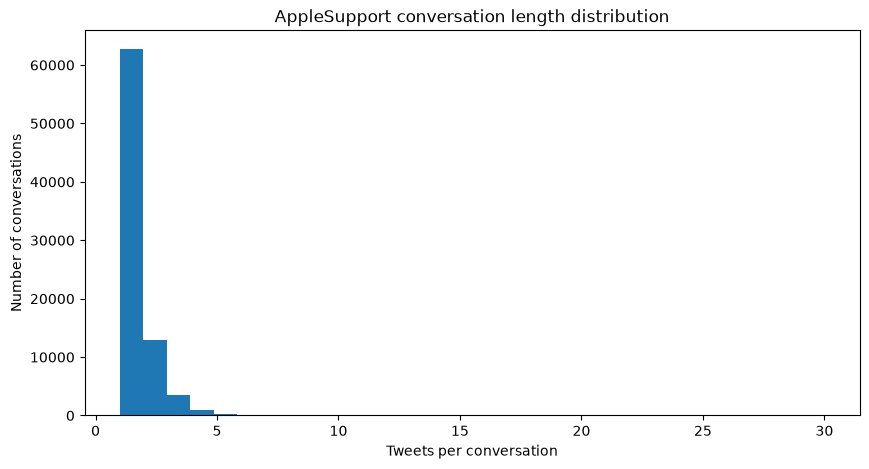

In [51]:
import matplotlib.pyplot as plt

conv_size.clip(upper=30).plot.hist(
    bins=30,
    figsize=(10, 5)
)

plt.xlabel("Tweets per conversation")
plt.ylabel("Number of conversations")
plt.title("AppleSupport conversation length distribution")
plt.show()

In [19]:
apple = data[data["author_id"].eq("AppleSupport")].copy()

In [20]:
pairs = apple[apple["inbound"].eq(False) & apple["in_response_to_tweet_id"].notna()].merge(
    data[["tweet_id", "author_id", "inbound", "text", "created_at"]],
    left_on="in_response_to_tweet_id",
    right_on="tweet_id",
    how="inner",
    suffixes=("_agent", "_customer")
)

In [21]:
pairs.head()

,tweet_id_agent,author_id_agent,inbound_agent,created_at_agent,text_agent,response_tweet_id,in_response_to_tweet_id,tweet_id_customer,author_id_customer,inbound_customer,text_customer,created_at_customer
0,696,AppleSupport,False,Tue Oct 31 22:27:49 +0000 2017,@115854 We're here for you. Which version of t...,697,698.0,698,115854,True,@AppleSupport https://t.co/NV0yucs0lB,Tue Oct 31 22:17:40 +0000 2017
1,699,AppleSupport,False,Tue Oct 31 22:36:27 +0000 2017,@115854 Lets take a closer look into this issu...,NaN,697.0,697,115854,True,@AppleSupport The newest update. I️ made sure ...,Tue Oct 31 22:31:23 +0000 2017
2,701,AppleSupport,False,Tue Oct 31 22:26:49 +0000 2017,@115855 Let's go to DM for the next steps. DM ...,NaN,702.0,702,115855,True,@AppleSupport Tried resetting my settings .. r...,Tue Oct 31 22:11:31 +0000 2017
3,703,AppleSupport,False,Tue Oct 31 22:09:52 +0000 2017,@115855 Any steps tried since it started last ...,702,704.0,704,115855,True,@AppleSupport This is what it looks like https...,Tue Oct 31 21:59:17 +0000 2017
4,705,AppleSupport,False,Tue Oct 31 21:57:00 +0000 2017,@115855 That's great it has iOS 11.1 as we can...,"706,704",707.0,707,115855,True,@AppleSupport I️ have an iPhone 7 Plus and yes...,Tue Oct 31 21:48:51 +0000 2017


In [22]:
pairs = pairs.rename(columns={
    "tweet_id_customer": "customer_tweet_id",
    "text_customer": "customer_text",
    "created_at_customer": "customer_created_at",
    "tweet_id_agent": "agent_tweet_id",
    "text_agent": "agent_text",
    "created_at_agent": "agent_created_at",
})

pairs = pairs[
    [
        "customer_tweet_id",
        "customer_text",
        "agent_tweet_id",
        "agent_text",
    ]
].drop_duplicates()

print(f"Created {len(pairs):,} customer → AppleSupport pairs")
display(pairs.head(10))

Created 106,648 customer → AppleSupport pairs


,customer_tweet_id,customer_text,agent_tweet_id,agent_text
0,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...
1,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...
2,702,@AppleSupport Tried resetting my settings .. r...,701,@115855 Let's go to DM for the next steps. DM ...
3,704,@AppleSupport This is what it looks like https...,703,@115855 Any steps tried since it started last ...
4,707,@AppleSupport I️ have an iPhone 7 Plus and yes...,705,@115855 That's great it has iOS 11.1 as we can...
5,709,@AppleSupport I️ need answers because it’s ann...,708,@115855 We'd like to look into this with you. ...
6,714,Hey @AppleSupport and anyone else who upgraded...,712,"@115856 Hey, let's work together to figure out..."
7,717,@AppleSupport This is what is happening... htt...,716,@115857 We'd like to investigate further with ...
8,719,Tf is wrong with my keyboard @115858,718,"@115857 Fill us in on what is happening, then ..."
9,721,@AppleSupport are the call centres closed for ...,720,@115859 We've received your DM and will contin...


In [23]:
import re

In [24]:
def clean_tweet(text):
    text = str(text)

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"\s+", " ", text)

    return text

In [25]:
pairs["customer_text"] = pairs["customer_text"].apply(clean_tweet)
pairs["agent_text"] = pairs["agent_text"].apply(clean_tweet)
pairs = pairs.drop_duplicates(
    subset=["customer_text", "agent_text"]
).reset_index(drop=True)

In [26]:
display(pairs[["customer_text", "agent_text"]].head(20))

,customer_text,agent_text
0,,We're here for you. Which version of the iOS ...
1,The newest update. I️ made sure to download i...,Lets take a closer look into this issue. Sele...
2,Tried resetting my settings .. restarting my ...,Let's go to DM for the next steps. DM us here:
3,This is what it looks like,Any steps tried since it started last night?
4,I️ have an iPhone 7 Plus and yes I️ do,That's great it has iOS 11.1 as we can rule o...
5,I️ need answers because it’s annoying 🙃,We'd like to look into this with you. Which m...
6,"Hey and anyone else who upgraded to ios11.1, a...","Hey, let's work together to figure out what's..."
7,This is what is happening...,We'd like to investigate further with you. Se...
8,Tf is wrong with my keyboard,"Fill us in on what is happening, then we can ..."
9,are the call centres closed for the night?,We've received your DM and will continue there.


In [27]:
len(pairs)

106518

In [ ]:
#lets inpect some samples
sample = pairs.sample(1000, random_state=42)

for i, text in enumerate(sample["customer_text"], 1):
    print(f"{i}, {text}")

In [91]:
# no way im reading all that in order to cluster them based on intent.

In [92]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import numpy as np

In [93]:
model = SentenceTransformer("all-MiniLM-L6-v2")
texts = sample["customer_text"].to_list()

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    normalize_embeddings=True
)
print("Embedding Shape: ", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding Shape:  (1000, 384)


In [94]:
# clustering the customer messages based in clusters of intents
k = 10 # 10 intents
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(embeddings)

sample = sample.copy()
sample["cluster"] = labels

print(sample["cluster"].value_counts().sort_index())

cluster
0    147
1    108
2     88
3    105
4    113
5     67
6    102
7     89
8     89
9     92
Name: count, dtype: int64


In [96]:
for cluster_id in range(10):
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*70}")
    
    examples = sample[
        sample["cluster"] == cluster_id
    ]["customer_text"].head(15)
    
    for text in examples:
        print("-", text)


CLUSTER 0
-  how to completely turn off wifi on ios11? It doesn't happen from control center
- ., Hi, I’m having issues with the keyboard in WhatsApp since update to iOS 11.0.2. Keyboard is in mid of screen.🙏
- Can reach out so I️ ,and other iphone users can get this bug fixed in an update. Am I️ the only one? I️ bet not
-  6s plus 11.0.3....
- #iOS 11.2 beta 4 problem with phone app not working properly. Fix ASAP 
-  Ios 11.1.2 ..in all apps ..the behavior of the ipad is so slow and and stuttering like said before ...in ios 10.3.3 every thing was smooth and satisfactory
-  how can I report the bug on new IOS?
-  Swtcd to Apple 4 1st Time iPhone 6 iOS 11 ruined my experience slower after every update this is not the same 🍎 I knew loosing faith in🍎😔
-  Why is iOS 11 draining my 6s plus battery😑😡
-  hi, I'm having trouble installing ios 11 and my phone keeps saying there's an error. What should I do?
-  I have tried 10+ times to install 11.1 and it has failed and asked me to try again l

In [98]:
# hmmm, its not bad, but still very ambiguous.

In [100]:
label_data = pairs.sample(500, random_state=42)[["customer_text"]].copy()
len(label_data)

500

In [ ]:
for i, text in enumerate(label_data["customer_text"], 1):
    print(f"{i}, {text}")

In [105]:
label_data = pd.read_csv("~/tweets/data/apple_support_500_labeled.csv")

In [109]:
trainable = label_data[
    label_data["intent"] != "Unknown"
    ].copy()
print("Trainable exps:", len(trainable))
print(trainable["intent"].value_counts())

Trainable exps: 316
intent
iOS Update Problems             75
Battery & Power                 49
Performance & Crashes           44
Keyboard & Typing               31
Account, Payments & Security    30
Connectivity                    24
Calls & Audio                   22
iCloud & Data Sync              20
Messages & iMessage             12
Notifications & Alarms           9
Name: count, dtype: int64


In [110]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    trainable["customer_text"],
    trainable["intent"],
    test_size=0.2,
    random_state=42,
    stratify=trainable["intent"]
)
print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 252
Test: 64


In [112]:
classifier = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

classifier.fit(X_train, y_train)

print("Classifier trained.")

Classifier trained.


In [113]:
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

                              precision    recall  f1-score   support

Account, Payments & Security       0.50      0.50      0.50         6
             Battery & Power       0.73      0.80      0.76        10
               Calls & Audio       0.25      0.20      0.22         5
                Connectivity       0.75      0.60      0.67         5
           Keyboard & Typing       0.45      0.83      0.59         6
         Messages & iMessage       1.00      0.50      0.67         2
      Notifications & Alarms       0.00      0.00      0.00         2
       Performance & Crashes       0.27      0.44      0.33         9
          iCloud & Data Sync       1.00      0.25      0.40         4
         iOS Update Problems       0.45      0.33      0.38        15

                    accuracy                           0.48        64
                   macro avg       0.54      0.45      0.45        64
                weighted avg       0.52      0.48      0.47        64



In [115]:
# that is a pretty crappy baseline for our classifier

In [117]:
results = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

errors = results[results["actual"] != results["predicted"]]

print(f"Errors: {len(errors)} / {len(results)}")
pd.set_option("display.max_colwidth", None)
display(errors.head(30))

Errors: 33 / 64


,text,actual,predicted
132,hello please refund MNWF00KQ9D order id. I wasnt able to use it. It wont show up on my phone thank you,"Account, Payments & Security",Keyboard & Typing
131,when does the pre order for the X start?,"Account, Payments & Security",iOS Update Problems
40,So annoying as I was trying to fix all the problems on my phone with the update and now I can't use it at all 😂,iOS Update Problems,Performance & Crashes
271,"yo iOS 11 is sooooo buggy and it’s making my phone crash every 20 minutes, rendering it useless amongst other issues 👎🏼👎🏼",Performance & Crashes,Battery & Power
253,that stupid update about the error on pictures and blurring them out is annoying asf is there any way I can take them out !!! Becoming really upset,iCloud & Data Sync,Battery & Power
3,"y’all need to fix this glitch going on , me can’t use that letter because it comes out looking like this I️ and then me look dumb so pls fix and me will love u forever",Performance & Crashes,Keyboard & Typing
362,Your iOS 11 update made my tablets non mobile. 2 tablets that could hold a charge for hours now don’t last 90 minutes. Fix this!,Battery & Power,Performance & Crashes
106,So any idea how to fix this “I” glitch??,Performance & Crashes,Keyboard & Typing
488,"This is me. It’s pissing me off, haven’t even had my phone a year and they know my upgrade is due in December",iOS Update Problems,Performance & Crashes
260,"new iPhone X apparently delivered today. No sign of it at my address, and according to a map on the UK mail tracking site they’ve been to completely the wrong address. Not impressed.","Account, Payments & Security",Connectivity


In [17]:
tweet_lookup = data.set_index("tweet_id").to_dict("index")

def get_conversation(tweet_id, max_messages=6):
    chain = trace_back(tweet_id, max_depth=50)

    messages = []
    for tid in chain:
        row = tweet_lookup.get(tid)
        if row is None:
            continue

        role = "Customer" if row["inbound"] else "AppleSupport"

        messages.append(
            f"{role}: {row['text']}"
        )

    return "\n".join(messages[-max_messages:])

In [33]:
test_20 = pairs.sample(20, random_state=123).copy()
test_20["state"] = test_20["customer_tweet_id"].apply(
    get_conversation
)
display(test_20[["customer_tweet_id", "customer_text", "state"]].head(20))

,customer_tweet_id,customer_text,state
64341,1921244,When ur iphone deletes all your messages,Customer: When ur iphone deletes all your mess...
47773,1616689,Fix this question mark shit NEOW,Customer: Fix this question mark shit NEOW @11...
64358,1921538,I’m part of the Apple upgrade program. If I c...,Customer: @AppleSupport I’m part of the Apple ...
60806,1845855,ios 11.0.3 battery draining faster than befor...,Customer: @AppleSupport ios 11.0.3 battery dra...
7361,290230,my phone is so fucked after this update. WHHY...,Customer: @AppleSupport my phone is so fucked ...
89050,2422472,its black constantly the screen wont turn on ...,Customer: @AppleSupport so can you tell me why...
100434,2773127,The customer service center and Apple Support...,Customer: @115858 The customer service center ...
25928,916873,What is this? It doesn't let me my security q...,Customer: @AppleSupport What is this? It doesn...
19214,687985,Yeah. I tried. No luck. Oh well.,Customer: somebody stole my iPad Pro this past...
51826,1680916,uh what's up with not being able to delete ap...,Customer: @115858 @AppleSupport uh what's up ...


In [124]:
gold = pairs.sample(100, random_state=42).copy()

gold["state"] = gold["customer_tweet_id"].apply(get_conversation)

gold = gold[
    gold["state"].notna() &
    gold["state"].str.strip().ne("")
].copy()

gold["expected_intent"] = ""

gold = gold[
    ["customer_tweet_id", "customer_text", "state", "expected_intent"]
].reset_index(drop=True)

display(gold.head())
print("Gold set size:", len(gold))

,customer_tweet_id,customer_text,state,expected_intent
0,1531363,"hey can you please explain why as soon as new phones go on sale, all the older phones magically stop working?","Customer: hey @AppleSupport can you please explain why as soon as new phones go on sale, all the older phones magically stop working?",
1,1222671,how to completely turn off wifi on ios11? It doesn't happen from control center,Customer: @AppleSupport how to completely turn off wifi on ios11? It doesn't happen from control center,
2,2371227,Alright so do I just use the turn on sound option then??,"Customer: Hi I've lost my iPhone and I have already tried tracking it but it's not location it because my iPhone doesn't have wifi bit I still put my track iPhone and lost mode on does that mean ignoring it finds wifi it will automatically make a sound? @applesupport\nCustomer: @AppleSupport I've already tracked it and put it as lost mode so does that me and if it does find connection it will make the sound? I'm very desperate and i don't know what to do. Thank you\nAppleSupport: @684211 Losing a device is never a fun experience. This can help you locate the device and what options Find my iPhone has: https://t.co/fUoKdx4Yut Try under the section titled, 'What if your device is off or offline?' In Lost Mode, it does not sound when it returns online.\nCustomer: @AppleSupport Alright so do I just use the turn on sound option then??",
3,2321867,"y’all need to fix this glitch going on , me can’t use that letter because it comes out looking like this I️ and then me look dumb so pls fix and me will love u forever","Customer: @115858 y’all need to fix this glitch going on , me can’t use that letter because it comes out looking like this I️ and then me look dumb so pls fix and me will love u forever",
4,672995,"., Hi, I’m having issues with the keyboard in WhatsApp since update to iOS 11.0.2. Keyboard is in mid of screen.🙏","Customer: .@4305, @AppleSupport Hi, I’m having issues with the keyboard in WhatsApp since update to iOS 11.0.2. Keyboard is in mid of screen.🙏",


Gold set size: 100


In [127]:
gold.to_csv(
    "~/tweets/data/apple_support_gold_100.csv",
    index=False
)

In [42]:
from typesafe_sdk import Choice, Noul, TypeSafeClient
import os

In [3]:
print(os.getenv("TYPESAFE_API_KEY") is not None)

True


In [58]:
criteria={
    "battery_power": "Battery draining, charging problems, unexpected shutdowns, battery health or power issues.",
    "performance_crashes": "Device is slow, freezing, lagging, crashing, restarting or becoming unresponsive.",
    "ios_update": "Problems installing, downloading, updating, or reverting an Apple OS",
    "keyboard_typing": "Keyboard, typing, autocorrect, or character-entry problems.",
    "messages_imessage": "Problems sending, receiving, activating, or syncing Messages or iMessage.",
    "calls_audio": "Phone calls, speaker, microphone, headphones, AirPods, or audio problems.",
    "connectivity": "Wi-Fi, Bluetooth, cellular, AirDrop, or network connection problems.",
    "notifications_alarms": "Notification or alarm problems.",
    "icloud_data_sync": "iCloud, backups, photos, files, or synchronization problems.",
    "account_payments_security": "Apple ID, passwords, verification, payments, subscriptions, refunds, purchases, security, or warranty issues.",
    "unknown": "The message is too short, vague, or context-dependent to determine "
    "the customer's primary support intent."
}

In [54]:
with TypeSafeClient() as client:
    response = client.system_one(
        state=state,
        questions=questions,
    )

answer = response.choices["intent"]

print("Intent:", answer.choice)
print("Confidence:", answer.confidence)
print("Probabilities:", answer.probabilities)

Intent: messages_imessage
Confidence: 0.99
Probabilities: {'connectivity': 0.0, 'battery_power': 0.0, 'notifications_alarms': 0.0, 'account_payments_security': 0.0, 'keyboard_typing': 0.0, 'performance_crashes': 0.0, 'icloud_data_sync': 0.01, 'calls_audio': 0.0, 'ios_update': 0.0, 'messages_imessage': 0.99}


In [55]:
def classify_intent(state):
    with TypeSafeClient() as client:
        response = client.system_one(
            state = {"conversation": state},
            questions={
                #"sufficient_context": Noul(
                #    instructions=(
                #        "Does the conversation have enough information to identify the customer's primary support intent?"
                #    )
                #),
                "intent": Choice(
                    instructions="What is the customer's primary support intent?",
                    criteria=criteria,
                )
            },
        )
    #context_ans = response.nouls["sufficient_context"]
    intent_ans = response.choices["intent"]
    
    return{
        #"sufficient_context": context_ans.noul,
        "intent": intent_ans.choice,
        "confidence": intent_ans.confidence,
        "probabilities": intent_ans.probabilities,
    }

In [50]:
state = test_20.iloc[0]["state"]

result = classify_intent(state)

#print("Customer:", test_20.iloc[0]["customer_text"])
print("Intent:", result["intent"])
print("Confidence:", result["confidence"])
print("Probabilities:", result["probabilities"])

Intent: messages_imessage
Confidence: 0.98
Probabilities: {'unknown': 0.0, 'battery_power': 0.0, 'keyboard_typing': 0.0, 'account_payments_security': 0.0, 'connectivity': 0.0, 'performance_crashes': 0.0, 'icloud_data_sync': 0.01, 'notifications_alarms': 0.0, 'calls_audio': 0.0, 'ios_update': 0.0, 'messages_imessage': 0.99}


In [56]:
jev_results = []

for _, row in test_20.iterrows():
    result = classify_intent(row["state"])

    jev_results.append({
        "customer_tweet_id": row["customer_tweet_id"],
        "customer_text": row["customer_text"],
        #"sufficient_context": result["sufficient_context"],
        "jev_intent": result["intent"],
        "confidence": result["confidence"],
    })

jev_results = pd.DataFrame(jev_results)

display(jev_results)

,customer_tweet_id,customer_text,jev_intent,confidence
0,1921244,When ur iphone deletes all your messages,messages_imessage,0.97
1,1616689,Fix this question mark shit NEOW,unknown,0.79
2,1921538,I’m part of the Apple upgrade program. If I c...,account_payments_security,0.60
3,1845855,ios 11.0.3 battery draining faster than befor...,battery_power,1.00
4,290230,my phone is so fucked after this update. WHHY...,ios_update,0.90
5,2422472,its black constantly the screen wont turn on ...,ios_update,0.72
6,2773127,The customer service center and Apple Support...,unknown,1.00
7,916873,What is this? It doesn't let me my security q...,account_payments_security,0.99
8,687985,Yeah. I tried. No luck. Oh well.,account_payments_security,0.42
9,1680916,uh what's up with not being able to delete ap...,unknown,0.89


In [57]:
jev_results.to_csv(
    "../data/jev_test_results_20.csv",
    index=False
)

AttributeError: 'DataFrame' object has no attribute 'display'